# Сергушов Павел ПМ22-4
# Лабораторная работа №2

## Загрузка датасета и библитек.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import ast

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity
from wordcloud import WordCloud, STOPWORDS
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [5]:
drive_path = '/content/drive/MyDrive/РекомСистем/The Movies Dataset/'

try:
    movies_df = pd.read_csv(drive_path + 'movies_metadata.csv', low_memory=False)
    keywords_df = pd.read_csv(drive_path + 'keywords.csv')
    credits_df = pd.read_csv(drive_path + 'credits.csv')
    links_df = pd.read_csv(drive_path + 'links.csv')
    # Начнем с малых данных для прототипирования
    ratings_small_df = pd.read_csv(drive_path + 'ratings_small.csv')
    links_small_df = pd.read_csv(drive_path + 'links_small.csv')

    print("Data loaded successfully!")
    print("Movies metadata shape:", movies_df.shape)
    print("Ratings small shape:", ratings_small_df.shape)

except FileNotFoundError:
    print(f"Ошибка: Один или несколько файлов не найдены. Проверьте пути в переменной 'drive_path' ({drive_path})")
except Exception as e:
    print(f"Произошла ошибка при загрузке данных: {e}")

Data loaded successfully!
Movies metadata shape: (45466, 24)
Ratings small shape: (100004, 4)


## Просмотр и предобработка данных.

### Проверяем пропуски

In [8]:
movies_df.isnull().sum()

,0
adult,0
belongs_to_collection,40972
budget,0
genres,0
homepage,37684
id,0
imdb_id,17
original_language,11
original_title,0
overview,954


In [9]:
credits_df.isnull().sum()

,0
cast,0
crew,0
id,0


In [10]:
ratings_small_df.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [11]:
ratings_small_df['rating'].value_counts()

,count
rating,
4.0,28750
3.0,20064
5.0,15095
3.5,10538
4.5,7723
2.0,7271
2.5,4449
1.0,3326
1.5,1687


In [12]:
keywords_df.isnull().sum()

,0
id,0
keywords,0


In [15]:
links_df.isnull().sum()

,0
movieId,0
imdbId,0
tmdbId,219


### Ищем дубликаты и удаляем их

In [18]:
movies_df.duplicated(subset='id').sum()

30

In [19]:
movies = movies_df.drop_duplicates(subset='id', keep='first')

In [20]:
movies.duplicated(subset='id').sum()

0

### Работаем с нечисловыми значениями

In [21]:
non_numeric_ids = pd.to_numeric(movies['id'], errors='coerce').isna()
print(f"\nКоличество нечисловых ID: {non_numeric_ids.sum()}")


Количество нечисловых ID: 3


In [22]:
movies[non_numeric_ids]

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
19730,- Written by Ørnås,0.065736,/ff9qCepilowshEtG2GYWwzt2bs4.jpg,"[{'name': 'Carousel Productions', 'id': 11176}...","[{'iso_3166_1': 'CA', 'name': 'Canada'}, {'iso...",1997-08-20,0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29503,Rune Balot goes to a casino connected to the ...,1.931659,/zV8bHuSL6WXoD6FWogP9j4x80bL.jpg,"[{'name': 'Aniplex', 'id': 2883}, {'name': 'Go...","[{'iso_3166_1': 'US', 'name': 'United States o...",2012-09-29,0,68.0,"[{'iso_639_1': 'ja', 'name': '日本語'}]",Released,...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35587,Avalanche Sharks tells the story of a bikini ...,2.185485,/zaSf5OG7V8X8gqFvly88zDdRm46.jpg,"[{'name': 'Odyssey Media', 'id': 17161}, {'nam...","[{'iso_3166_1': 'CA', 'name': 'Canada'}]",2014-01-01,0,82.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
movies = movies[~non_numeric_ids]
movies.dropna(subset=['imdb_id'], inplace=True)

movies.dropna(subset=['original_language'], inplace=True)
movies.dropna(subset=['title'], inplace=True)
movies.dropna(subset=['vote_average', 'vote_count'], inplace=True)

movies['popularity'] = pd.to_numeric(movies['popularity'], errors='coerce')
movies['popularity'].fillna(0, inplace=True)

movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies.dropna(subset=['release_date'], inplace=True)

movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce')
movies['budget'].fillna(0, inplace=True)
movies['budget'] = movies['budget'].astype(int)

movies['revenue'].fillna(0, inplace=True)
movies['revenue'] = movies['revenue'].astype(float)

movies['runtime'].fillna(0, inplace=True)

movies['overview'].fillna('', inplace=True)
movies['tagline'].fillna('', inplace=True)

In [27]:
print(movies['adult'].value_counts())
movies = movies[movies['adult'] == 'False']

adult
False    45313
Name: count, dtype: int64


In [28]:
movies.drop('adult', axis=1, inplace=True)
movies.isnull().sum()

,0
belongs_to_collection,40830
budget,0
genres,0
homepage,37554
id,0
imdb_id,0
original_language,0
original_title,0
overview,0
popularity,0


Остались пропущенные значение. Обрабатываем дальше.


In [ ]:
movies['belongs_to_collection'].fillna('None', inplace=True)
movies['homepage'].fillna('None', inplace=True)

In [32]:
cols_to_drop = ['poster_path', 'spoken_languages', 'status', 'video',
                'production_companies', 'production_countries', 'tagline']

In [33]:
movies.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [34]:
movies.isnull().sum()

,0
belongs_to_collection,0
budget,0
genres,0
homepage,0
id,0
imdb_id,0
original_language,0
original_title,0
overview,0
popularity,0


Предобработака выполнена

Парсинг

In [41]:
movies['id'] = pd.to_numeric(movies['id'], errors='raise').astype('int64')
credits_df['id'] = pd.to_numeric(credits_df['id'], errors='raise').astype('int64')
keywords_df['id'] = pd.to_numeric(keywords_df['id'], errors='raise').astype('int64')

In [43]:
movies_clean = movies.copy()
credits_clean = credits_df.copy()
keywords_clean = keywords_df.copy()

In [44]:
movies_merged = movies_clean.merge(credits_clean, on='id', how='inner')
movies_merged = movies_merged.merge(keywords_clean, on='id', how='inner')

In [45]:
def safe_literal_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return x  # Вернуть как есть, если не удаётся преобразовать
    return x

In [46]:
features_to_parse = ['genres', 'cast', 'crew', 'keywords']

In [47]:
for feature in features_to_parse:
    if feature in movies_merged.columns:
        print(f"Обработка столбца: {feature}")
        movies_merged[feature] = movies_merged[feature].apply(safe_literal_eval)

Обработка столбца: genres
Обработка столбца: cast
Обработка столбца: crew
Обработка столбца: keywords


In [49]:
if 'genres' in movies_merged.columns:
    print("\nПример значения в 'genres' после парсинга:")
    print(movies_merged['genres'].iloc[1])


Пример значения в 'genres' после парсинга:
[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, 'name': 'Family'}]


## Визуализация данных.

In [50]:
all_genres = []
if 'genres' in movies_merged.columns:
    movies_merged['genres'].apply(lambda x: [all_genres.append(i['name']) for i in x if isinstance(i, dict) and 'name' in i])

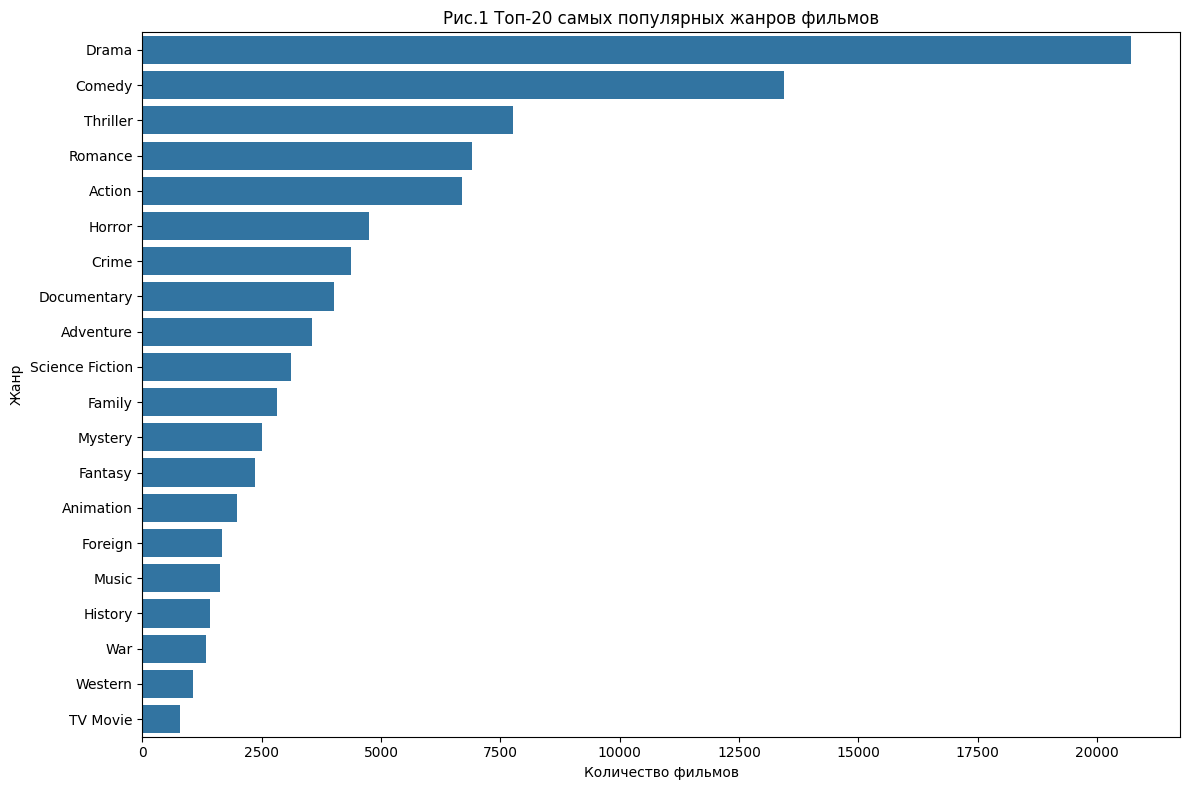

In [54]:
if all_genres:
    genres_counts = pd.Series(all_genres).value_counts()

    plt.figure(figsize=(12, 8))
    sns.barplot(x=genres_counts.head(20).values, y=genres_counts.head(20).index)
    plt.title('Рис.1 Топ-20 самых популярных жанров фильмов')
    plt.xlabel('Количество фильмов')
    plt.ylabel('Жанр')
    plt.tight_layout()
    plt.show()

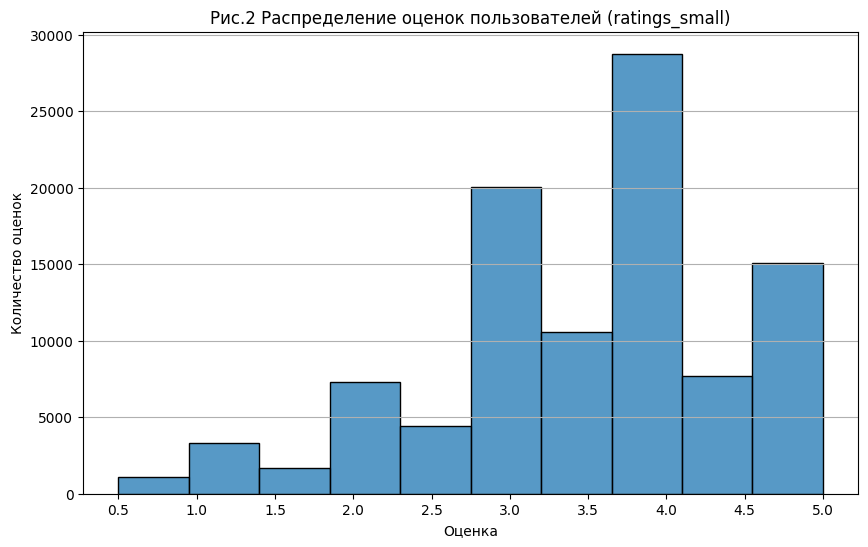

In [55]:
plt.figure(figsize=(10, 6))
sns.histplot(ratings_small_df['rating'], bins=10, kde=False)
plt.title('Рис.2 Распределение оценок пользователей (ratings_small)')
plt.xlabel('Оценка')
plt.ylabel('Количество оценок')
plt.xticks(np.arange(0.5, 5.5, 0.5))
plt.grid(True, axis='y')
plt.show()

Датасет характеризуется доминированием определенных жанров (Драма, Комедия) и тенденцией пользователей ставить преимущественно положительные оценки, с наиболее частой оценкой 4.0. Эти особенности необходимо учитывать при дальнейшей разработке и оценке рекомендательных систем.

### Матрица корреляции

In [56]:
numeric_cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']

In [57]:
correlation_matrix = movies_merged[numeric_cols].corr()

<Axes: >

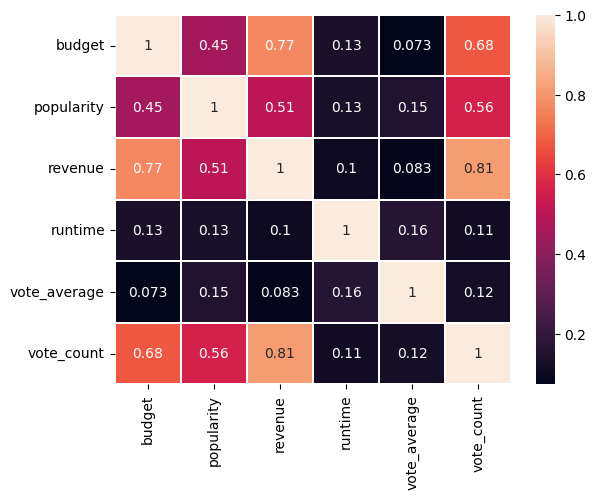

In [58]:
sns.heatmap(correlation_matrix, annot=True, linewidths=.25)

In [59]:
all_keywords = []
movies_merged['keywords'].apply(lambda x: [all_keywords.append(i['name']) for i in x if isinstance(i, dict) and 'name' in i and i['name'] is not None])

,keywords
0,"[None, None, None, None, None, None, None, Non..."
1,"[None, None, None, None, None, None]"
2,"[None, None, None, None]"
3,"[None, None, None, None, None]"
4,"[None, None, None, None, None, None, None, Non..."
...,...
46370,[]
46371,"[None, None, None]"
46372,[]
46373,[]


In [60]:
movies_merged['keywords']

,keywords
0,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."
...,...
46370,[]
46371,"[{'id': 2679, 'name': 'artist'}, {'id': 14531,..."
46372,[]
46373,[]


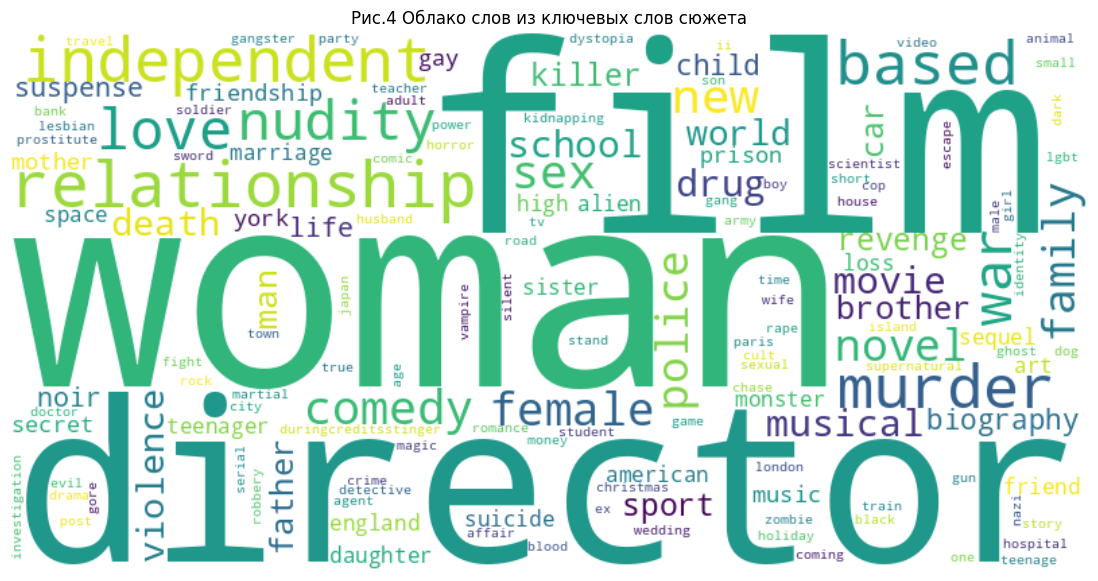

In [62]:
keywords_text = ' '.join(all_keywords)

stopwords = set(STOPWORDS)

wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords,
                      max_words=150, collocations=False).generate(keywords_text) # collocations=False чтобы избежать фраз

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Рис.4 Облако слов из ключевых слов сюжета')
plt.show()

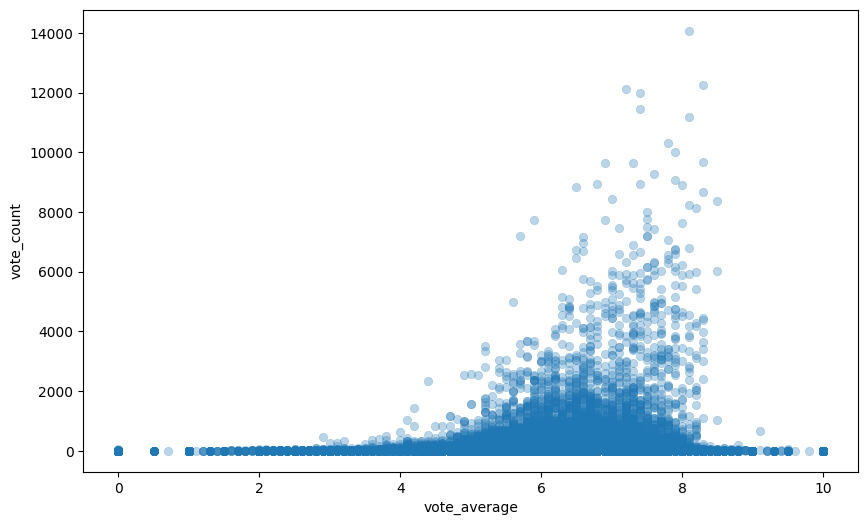

In [63]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='vote_average', y='vote_count', data=movies_merged, alpha=0.3, edgecolor=None)
plt.xlabel('vote_average')
plt.ylabel('vote_count')
plt.show()

## Простая рекомендательная система.

In [64]:
C = movies_merged['vote_average'].mean()
print(f"\nСредний рейтинг по всем фильмам (C): {C:.4f}")

m = movies_merged['vote_count'].quantile(0.95)
print(f"Минимальное количество голосов для включения (m, 95-й перцентиль): {m:.0f}")


Средний рейтинг по всем фильмам (C): 5.6190
Минимальное количество голосов для включения (m, 95-й перцентиль): 428


In [65]:
qualified_movies = movies_merged.copy()[movies_merged['vote_count'] >= m]

v = qualified_movies['vote_count']
R = qualified_movies['vote_average']

qualified_movies['weighted_rating'] = (v / (v + m) * R) + (m / (v + m) * C)

qualified_movies = qualified_movies.sort_values('weighted_rating', ascending=False)
print("\nТоп-15 фильмов по взвешенному рейтингу IMDB:")
qualified_movies[['title', 'vote_count', 'vote_average', 'weighted_rating', 'release_date']].head(15)


Топ-15 фильмов по взвешенному рейтингу IMDB:


,title,vote_count,vote_average,weighted_rating,release_date
314,The Shawshank Redemption,8358.0,8.5,8.359655,1994-09-23
835,The Godfather,6024.0,8.5,8.308886,1972-03-14
12519,The Dark Knight,12269.0,8.3,8.209627,2008-07-16
2852,Fight Club,9678.0,8.3,8.186457,1999-10-15
292,Pulp Fiction,8670.0,8.3,8.173877,1994-09-10
351,Forrest Gump,8147.0,8.2,8.071176,1994-07-06
522,Schindler's List,4436.0,8.3,8.064090,1993-11-29
23705,Whiplash,4376.0,8.3,8.061143,2014-10-10
5497,Spirited Away,3968.0,8.3,8.038975,2001-07-20
1161,The Empire Strikes Back,5998.0,8.2,8.028094,1980-05-17


### Добавление фильтрации по жанру

In [66]:
target_genre = 'Drama'

In [68]:
genre_filtered_movies = qualified_movies[qualified_movies['genres'].apply(lambda x: target_genre in [i['name'] for i in x])]

genre_filtered_movies = genre_filtered_movies.sort_values('weighted_rating', ascending=False)

genre_filtered_movies[['title', 'vote_count', 'vote_average', 'weighted_rating', 'release_date']].head(10)


,title,vote_count,vote_average,weighted_rating,release_date
314,The Shawshank Redemption,8358.0,8.5,8.359655,1994-09-23
835,The Godfather,6024.0,8.5,8.308886,1972-03-14
12519,The Dark Knight,12269.0,8.3,8.209627,2008-07-16
2852,Fight Club,9678.0,8.3,8.186457,1999-10-15
351,Forrest Gump,8147.0,8.2,8.071176,1994-07-06
522,Schindler's List,4436.0,8.3,8.064090,1993-11-29
23705,Whiplash,4376.0,8.3,8.061143,2014-10-10
2217,Life Is Beautiful,3643.0,8.3,8.018136,1997-12-20
18522,The Intouchables,5410.0,8.2,8.010780,2011-11-02
22914,Interstellar,11187.0,8.1,8.008578,2014-11-05


1. Подтверждение Качества: Система действительно успешно идентифицирует фильмы, которые широко признаны критиками и зрителями как высококачественные и популярные (например, "Побег из Шоушенка", "Крестный отец", "Темный рыцарь"). Это подтверждает, что формула взвешенного рейтинга работает для выявления "общепризнанных хитов".

2. Стабильность Рейтинга: Верхние позиции в списке занимают фильмы с очень высоким средним рейтингом (vote_average 8.1-8.5) и большим количеством голосов (vote_count). Это делает топ списка довольно стабильным – чтобы новый фильм попал сюда, ему нужно не только получить высокий средний балл, но и собрать огромное количество голосов, что требует времени и широкой популярности.

3. Эффективность Фильтрации по Жанру: Как видно из второго примера (фильтрация по 'Drama'), система корректно отбирает фильмы указанного жанра и ранжирует их по тому же принципу взвешенного рейтинга. Это полезно, но не решает проблему персонализации – это просто "лучшие драмы для всех". Заметим, что многие фильмы из общего топа просто перекочевали в топ драм, что ожидаемо, так как драма – очень популярный и часто высокооцененный жанр.

4. Смещение к "Классике" и Устоявшимся Фильмам: В топе преобладают фильмы, выпущенные достаточно давно (много фильмов 90-х, 70-х, 00-х). Это логично, так как у них было больше времени, чтобы накопить большое количество голосов (vote_count), необходимое для высокого взвешенного рейтинга и преодоления порога m. Новые, даже очень хорошие фильмы, будут появляться в этом топе с задержкой.

5. Игнорирование Нюансов Вкуса: Система не различает, почему фильм популярен. "Темный рыцарь" (супергеройский боевик/триллер), "Криминальное чтиво" (нелинейный криминал) и "Форрест Гамп" (драма/комедия) – очень разные фильмы, хотя и находятся рядом в рейтинге. Пользователь, которому понравился один, не обязательно оценит другой, но система предложит их все как одинаково "лучшие".

6. Проблема "Длинного Хвоста": Система полностью игнорирует менее известные фильмы ("длинный хвост" распределения популярности), даже если они могут быть идеальными для конкретного пользователя. Она сосредоточена исключительно на "голове" – самых популярных и высокооцененных фильмах.

7. Чувствительность к Параметру m: Выбор порога m (минимальное количество голосов) напрямую влияет на состав списка. Слишком низкий m может привести к попаданию в топ фильмов с высоким рейтингом, но основанным на малом количестве мнений (что может быть нерепрезентативно). Слишком высокий m усиливает смещение в сторону только самых известных блокбастеров/классики.

В сухом остатке: это хороший инструмент для создания общего "Зала славы" фильмов или базовых рекомендаций при полном отсутствии информации о пользователе, но он совершенно не подходит для предоставления по-настоящему личных рекомендаций.

## Контентная рекомендательная система.

In [69]:
titles = movies_merged['title']
indices = pd.Series(movies_merged.index, index=movies_merged['title']).drop_duplicates()

In [70]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)

tfidf_matrix = tfidf_vectorizer.fit_transform(movies_merged['overview'])

target_movie_title = 'The Godfather'

In [71]:
if target_movie_title in indices:
    idx = indices[target_movie_title]

    # Получаем TF-IDF вектор только для целевого фильма
    target_movie_vector = tfidf_matrix[idx]

    # Вычисляем сходство между целевым фильмом и ВСЕМИ фильмами в матрице
    # Результат будет иметь размер (1, N), что требует гораздо меньше памяти
    sim_scores_vector = cosine_similarity(target_movie_vector, tfidf_matrix)

    # sim_scores_vector[0] - это массив сходств для нашего фильма со всеми остальными
    sim_scores = list(enumerate(sim_scores_vector[0]))

    # Дальше сортировка и вывод, как раньше
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11] # Исключаем сам фильм (сходство 1.0)
    movie_indices = [i[0] for i in sim_scores]
    recommended_titles = titles.iloc[movie_indices]
    print(recommended_titles)
else:
    print(f"Фильм '{target_movie_title}' не найден в базе данных.")

28205    Eurocrime! The Italian Cop and Gangster Films ...
1185                                The Godfather: Part II
29                                          Shanghai Triad
15776                                         Urban Menace
44957                     The Godfather Trilogy: 1972-1990
26337                                   Beck 28 - Familjen
41893                                            Brimstone
30522                       Bonnie and Clyde Italian Style
9607                                       I Remember Mama
11358                                      Dante's Inferno
Name: title, dtype: object


1. Была создана TF-IDF матрица для описаний фильмов, ограниченная 1000 наиболее частыми словами (без английских стоп-слов).

2. Найден TF-IDF вектор для "The Godfather".

3. Вычислено косинусное сходство между вектором "The Godfather" и векторами всех фильмов в базе.

4. Результаты отсортированы по убыванию сходства.

5. Выведены названия 10 фильмов с наибольшим сходством (исключая сам "The Godfather").

В списке рекомендованных фильмов присутствуют как ожидаемые ("The Godfather: Part II", "The Godfather Trilogy"), так и другие фильмы, чьи описания оказались наиболее близки по содержанию согласно TF-IDF и косинусному сходству (например, фильмы с криминальной или итальянской тематикой).

## Более сложная контентная система (Metadata Soup)

In [72]:
def get_director(x):
    for i in x:
        if isinstance(i, dict) and i.get('job') == 'Director':
            return i.get('name', '')
    return ''

In [73]:
def get_top_actors(x, n=3):
    actors = [i.get('name', '') for i in x if isinstance(i, dict)]
    return actors[:n]

In [74]:
movies_merged['director'] = movies_merged['crew'].apply(get_director)
movies_merged['actors'] = movies_merged['cast'].apply(get_top_actors)

movies_merged['genres_list'] = movies_merged['genres'].apply(lambda x: [i['name'] for i in x if isinstance(i, dict)])
movies_merged['keywords_list'] = movies_merged['keywords'].apply(lambda x: [i['name'] for i in x if isinstance(i, dict)])

In [75]:
def clean_name(name):
    if isinstance(name, str):
        return name.lower().replace(' ', '')
    return ''

def clean_list_of_names(lst):
    if isinstance(lst, list):
        return [clean_name(name) for name in lst]
    return []

In [76]:
movies_merged['director_clean'] = movies_merged['director'].apply(clean_name)
movies_merged['actors_clean'] = movies_merged['actors'].apply(clean_list_of_names)
movies_merged['genres_clean'] = movies_merged['genres_list'].apply(clean_list_of_names)
movies_merged['keywords_clean'] = movies_merged['keywords_list'].apply(clean_list_of_names)


In [77]:
def create_soup(x):
    director = [x['director_clean']] * 3 if x['director_clean'] else [] # 3 раза для большего веса
    return ' '.join(director + x['actors_clean'] + x['genres_clean'] + x['keywords_clean'])

In [78]:
movies_merged['metadata_soup'] = movies_merged.apply(create_soup, axis=1)

In [80]:
print("\nПример 'metadata_soup' для первого фильма:")
print(movies_merged['metadata_soup'].iloc[0])


Пример 'metadata_soup' для первого фильма:
johnlasseter johnlasseter johnlasseter tomhanks timallen donrickles animation comedy family jealousy toy boy friendship friends rivalry boynextdoor newtoy toycomestolife


In [81]:
count_vectorizer_soup = CountVectorizer(stop_words='english')
count_matrix_soup = count_vectorizer_soup.fit_transform(movies_merged['metadata_soup'])

In [82]:
print(f"\nРазмер Count матрицы для 'metadata_soup': {count_matrix_soup.shape}")


Размер Count матрицы для 'metadata_soup': (46375, 83592)


In [83]:
target_movie_title_soup = "Fight Club"

In [84]:
if target_movie_title_soup in indices:
        # 1. Получаем индекс целевого фильма
        idx_soup = indices[target_movie_title_soup]

        # 2. Получаем вектор признаков для целевого фильма из матрицы
        target_movie_vector_soup = count_matrix_soup[idx_soup]

        # 3. Вычисляем косинусное сходство между вектором целевого фильма
        #    и всеми векторами в матрице count_matrix_soup.
        #    Результат будет массивом формы (1, N), где N - кол-во фильмов.
        sim_scores_vector_soup = cosine_similarity(target_movie_vector_soup, count_matrix_soup)

        # 4. Преобразуем результат в список пар (индекс_фильма, сходство)
        #    Берем sim_scores_vector_soup[0], так как у нас только одна строка результата
        sim_scores_soup = list(enumerate(sim_scores_vector_soup[0]))

        # 5. Сортируем список по убыванию сходства (второй элемент пары)
        sim_scores_soup = sorted(sim_scores_soup, key=lambda x: x[1], reverse=True)

        # 6. Отбираем топ-10 самых похожих, исключая сам фильм (он будет первым с score=1.0)
        #    Берем срезы с 1 по 11 (индексы 1, 2, ..., 10)
        sim_scores_soup = sim_scores_soup[1:11]

        # 7. Получаем индексы рекомендованных фильмов
        movie_indices_soup = [i[0] for i in sim_scores_soup]

        # 8. Получаем названия рекомендованных фильмов по их индексам
        recommended_titles_soup = titles.iloc[movie_indices_soup]
        print(recommended_titles_soup)

        # (Опционально) Выведем детали первой рекомендации
        if movie_indices_soup:
             rec_index_detail = movie_indices_soup[0]
             print("\nДетали первой рекомендации:")
             detail_cols = ['title', 'director', 'actors', 'genres_list']
             existing_detail_cols = [col for col in detail_cols if col in movies_merged.columns]
             print(movies_merged.iloc[rec_index_detail][existing_detail_cols])

else:
    # Если фильм не найден в индексе
    print(f"Фильм '{target_movie_title_soup}' не найден в базе данных ('indices').")

13257    The Curious Case of Benjamin Button
1557                                The Game
5148                              Panic Room
46                                     Se7en
15857                     The Social Network
23707                              Gone Girl
11685                                 Zodiac
18351        The Girl with the Dragon Tattoo
1280                                  Alien³
1634                        Ill Gotten Gains
Name: title, dtype: object

Детали первой рекомендации:
title                   The Curious Case of Benjamin Button
director                                      David Fincher
actors           [Cate Blanchett, Brad Pitt, Tilda Swinton]
genres_list    [Fantasy, Drama, Thriller, Mystery, Romance]
Name: 13257, dtype: object


1. Скрипт успешно нашел целевой фильм (название не видно в этом фрагменте, но target_movie_title_soup было найдено в indices) в базе данных.

2. Были сгенерированы рекомендации на основе "супа метаданных" (вероятно, комбинации жанров, режиссера, актеров, ключевых слов и т. д.), векторизованного с помощью CountVectorizer (судя по названию count_matrix_soup) и сравненного с использованием косинусного сходства.

3. Выведен список из 10 наиболее похожих фильмов, исключая сам целевой фильм. Первым в списке рекомендаций идет "The Curious Case of Benjamin Button".

4. Дополнительно выведена подробная информация (название, режиссер, актеры, жанры) для самой первой (наиболее похожей) рекомендации — "The Curious Case of Benjamin Button" режиссера Дэвида Финчера.

5. Судя по списку рекомендаций (многие фильмы Дэвида Финчера), можно предположить, что целевым фильмом также был фильм этого режиссера, и данный метод успешно находит фильмы, схожие по составу съемочной группы и жанрам.

## Коллаборативная фильтрация (SVD)

In [85]:
reader = Reader(rating_scale=(1, 5))

In [87]:
data = Dataset.load_from_df(ratings_small_df[['userId', 'movieId', 'rating']], reader)

In [88]:
alg = SVD()

In [89]:
results = cross_validate(alg, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8917  0.8980  0.9002  0.9053  0.8901  0.8971  0.0056  
MAE (testset)     0.6886  0.6885  0.6918  0.6971  0.6855  0.6903  0.0040  
Fit time          1.81    1.57    1.00    1.02    1.04    1.29    0.34    
Test time         0.18    0.09    0.08    0.09    0.10    0.11    0.04    


In [90]:
avg_rmse = results['test_rmse'].mean()
avg_mae = results['test_mae'].mean()
print(f"Средний RMSE: {avg_rmse:.4f}")
print(f"Средний MAE: {avg_mae:.4f}")

Средний RMSE: 0.8971
Средний MAE: 0.6903


In [91]:
trainset = data.build_full_trainset()
alg.fit(trainset)

In [92]:
target_user_id = 1
print(f"\nРекомендации для пользователя userId={target_user_id}:")


Рекомендации для пользователя userId=1:


In [95]:
user_rated_movies = ratings_small_df[ratings_small_df['userId'] == target_user_id]['movieId'].tolist()
all_movie_ids = movies_merged['id'].unique()

In [96]:
user_unrated_movies = [movie_id for movie_id in all_movie_ids if movie_id not in user_rated_movies]

In [97]:
predictions = []
for movie_id in user_unrated_movies:
    # predict возвращает объект prediction с полем 'est' (estimated rating)
    predicted_rating = alg.predict(target_user_id, movie_id).est
    predictions.append((movie_id, predicted_rating))

In [98]:
predictions.sort(key=lambda x: x[1], reverse=True)
top_n_recommendations = predictions[:10]

## Холодный старт

In [99]:
print(f"\nТоп-10 фильмов, рекомендованных для пользователя {target_user_id}:")
# Создадим словарь id -> title для быстрого поиска названий
movie_id_to_title = pd.Series(movies_merged.title.values, index=movies_merged.id).to_dict()
for movie_id, predicted_rating in top_n_recommendations:
    movie_title = movie_id_to_title.get(movie_id, f"ID: {movie_id}") # Получаем название или ID
    print(f"- {movie_title} (Предсказанный рейтинг: {predicted_rating:.2f})")


Топ-10 фильмов, рекомендованных для пользователя 1:
- The 39 Steps (Предсказанный рейтинг: 3.69)
- Sleepless in Seattle (Предсказанный рейтинг: 3.66)
- Murder She Said (Предсказанный рейтинг: 3.66)
- The Million Dollar Hotel (Предсказанный рейтинг: 3.64)
- Galaxy Quest (Предсказанный рейтинг: 3.63)
- Don't Worry, I'm Fine (Предсказанный рейтинг: 3.62)
- The Good Shepherd (Предсказанный рейтинг: 3.59)
- Once Were Warriors (Предсказанный рейтинг: 3.57)
- Flags of Our Fathers (Предсказанный рейтинг: 3.57)
- Broken Blossoms (Предсказанный рейтинг: 3.56)


* Метод: Рекомендации основаны на предсказанных рейтингах. Некий алгоритм (не показанный в этом фрагменте кода, но результаты которого хранятся в top_n_recommendations) рассчитал, какие фильмы пользователь 1, вероятно, оценил бы наиболее высоко.

* Реализация:

1. Создается словарь movie_id_to_title для быстрого сопоставления ID фильма с его названием.

2. Код итерирует по списку top_n_recommendations, который содержит пары (ID фильма, предсказанный рейтинг).

3. Для каждого ID извлекается название фильма и выводится вместе с предсказанным рейтингом, отформатированным до двух знаков после запятой.

4. Результат: Для пользователя 1 были успешно сформированы и выведены 10 фильмов с самыми высокими предсказанными рейтингами, начиная с "The 39 Steps" (рейтинг 3.69) и заканчивая "Broken Blossoms" (рейтинг 3.56).

5. Контекст: Заголовок "Холодный старт" указывает, что эти рекомендации, вероятно, сгенерированы для пользователя с малым количеством или полным отсутствием предыдущих оценок, что является типичной проблемой для рекомендательных систем.

